<div style="background:linear-gradient(135deg,#001F3F 0%,#0093D5 100%);padding:40px 32px;border-left:6px solid #EE3A43;">
<h1 style="color:#FFFFFF;font-family:Arial,sans-serif;font-size:28px;margin:0 0 8px;">01 — Complaints Analysis</h1>
<h2 style="color:rgba(255,255,255,.75);font-family:Arial,sans-serif;font-size:16px;font-weight:400;margin:0 0 20px;">SpiriCom · NOC Intelligence Platform · Huawei Technologies Tunisia</h2>
<div style="display:flex;gap:32px;flex-wrap:wrap;">
<div style="color:rgba(255,255,255,.65);font-size:13px;"><strong style="color:#fff;">Dataset</strong><br/>real_complaints.xlsx — 2025 Complaints</div>
<div style="color:rgba(255,255,255,.65);font-size:13px;"><strong style="color:#fff;">Input</strong><br/>data/processed/complaints_clean.parquet</div>
<div style="color:rgba(255,255,255,.65);font-size:13px;"><strong style="color:#fff;">Outputs</strong><br/>data/outputs/figures/ + analysis_results.json</div>
</div>
</div>

In [1]:
# ═══════════════════════════════════════════════════════════════════════
# 0.  IMPORTS & GLOBAL STYLE
# ═══════════════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import matplotlib.colors as mcolors
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import json
import warnings
from pathlib import Path
from datetime import datetime

warnings.filterwarnings('ignore')

# ── Paths ─────────────────────────────────────────────────────────────
PROC_DIR = Path('data/processed')
FIG_DIR  = Path('data/outputs/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ── Huawei Brand Palette ──────────────────────────────────────────────
HW = dict(
    blue     = '#0093D5',
    red      = '#EE3A43',
    navy     = '#001F3F',
    cyan     = '#00C3FF',
    green    = '#22C55E',
    amber    = '#F59E0B',
    purple   = '#8B5CF6',
    orange   = '#F97316',
    bg_dark  = '#0D1117',
    bg_light = '#F0F4F8',
    text     = '#0D1117',
    muted    = '#6B7280',
)

# A palette list for multi-category charts
PALETTE = [
    HW['blue'], HW['red'], HW['cyan'], HW['green'],
    HW['amber'], HW['purple'], HW['orange'], HW['navy'],
    '#22D3EE', '#A855F7', '#FB923C', '#34D399',
]

# ── Matplotlib global style ───────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor'    : 'white',
    'axes.facecolor'      : 'white',
    'axes.edgecolor'      : '#E5E7EB',
    'axes.labelcolor'     : HW['navy'],
    'axes.labelweight'    : 'bold',
    'axes.labelsize'      : 11,
    'axes.titlesize'      : 13,
    'axes.titleweight'    : 'bold',
    'axes.titlecolor'     : HW['navy'],
    'axes.spines.top'     : False,
    'axes.spines.right'   : False,
    'axes.grid'           : True,
    'axes.grid.axis'      : 'y',
    'grid.color'          : '#F3F4F6',
    'grid.linewidth'      : 0.8,
    'xtick.color'         : HW['muted'],
    'ytick.color'         : HW['muted'],
    'xtick.labelsize'     : 9,
    'ytick.labelsize'     : 9,
    'legend.fontsize'     : 9,
    'legend.framealpha'   : 0.92,
    'legend.edgecolor'    : '#E5E7EB',
    'font.family'         : 'DejaVu Sans',
    'figure.dpi'          : 120,
    'savefig.dpi'         : 300,
    'savefig.bbox'        : 'tight',
    'savefig.facecolor'   : 'white',
})

# ── Plotly template ───────────────────────────────────────────────────
import plotly.io as pio
pio.templates.default = 'plotly_white'

PLOTLY_LAYOUT = dict(
    font          = dict(family='Arial, sans-serif', color=HW['navy']),
    paper_bgcolor = 'white',
    plot_bgcolor  = 'white',
    title_font    = dict(size=16, color=HW['navy'], family='Arial'),
    colorway      = PALETTE,
    margin        = dict(l=60, r=40, t=80, b=60),
    legend        = dict(bgcolor='rgba(255,255,255,0.9)',
                         bordercolor='#E5E7EB', borderwidth=1),
)

# ── Helper: add Huawei watermark ─────────────────────────────────────
def add_watermark(fig, text='SpiriCom · Huawei Technologies Tunisia'):
    fig.text(0.99, 0.01, text,
             ha='right', va='bottom',
             fontsize=7, color=HW['muted'],
             style='italic', transform=fig.transFigure)

def save_fig(fig, name, tight=True):
    path = FIG_DIR / f'{name}.png'
    if tight:
        plt.savefig(path, dpi=300, bbox_inches='tight')
    else:
        plt.savefig(path, dpi=300)
    print(f'  Saved: {path}')
    return path

print(' Style configuration loaded')
print(f'   Figures will be saved to: {FIG_DIR.resolve()}')

 Style configuration loaded
   Figures will be saved to: C:\Users\c50057188\Desktop\PFE_Ouerghi\data\outputs\figures


---
##  Section 1 — Overview Statistics
High-level summary of the complaints dataset: total volume, date coverage, unique customers, and geographic spread.

In [2]:
# ── 1.1  Load data ────────────────────────────────────────────────────
df = pd.read_parquet(PROC_DIR / 'complaints_clean.parquet')
print(f'Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head(3)

Loaded: 25,727 rows × 23 columns


,case_id,system,opened_at,complaint_type,msisdn,status,provider_group,typology,category,sub_category,...,segment,cust_code,contact_name,week,year,month,day_of_week,quarter,week_num,is_unresolved
0,TT546791,DCLM,2025-01-01 00:44:14,COMPLAINT,003760,CLOSED,GIS,NETWORK,RÉSEAU,RÉCLAMATION RÉSEAU MOBILE DATA,...,PREMIUM,1.60474609,BASSEM MAHMDI,NaN,2025,1,2,1,1,0
1,TT546829,DCLM,2025-01-01 08:21:08,COMPLAINT,366910,RESOLVED,GIS,NETWORK,RÉSEAU,RÉCLAMATION RÉSEAU MOBILE VOIX,...,LOWENDUSER,5.39863.10.00.104360,Amicale du Ministère de lAgriculture,NaN,2025,1,2,1,1,0
2,TT547176,DCLM,2025-01-01 11:30:40,COMPLAINT,44752050,CLOSED,GIS,NETWORK,RÉSEAU,RÉCLAMATION RÉSEAU MOBILE DATA,...,LOWENDUSER,5.57107.00.00.101444,Amicale Agents Territoire Metlaoui CPJ,NaN,2025,1,2,1,1,0


  Saved: data\outputs\figures\fig01_kpi_tiles.png


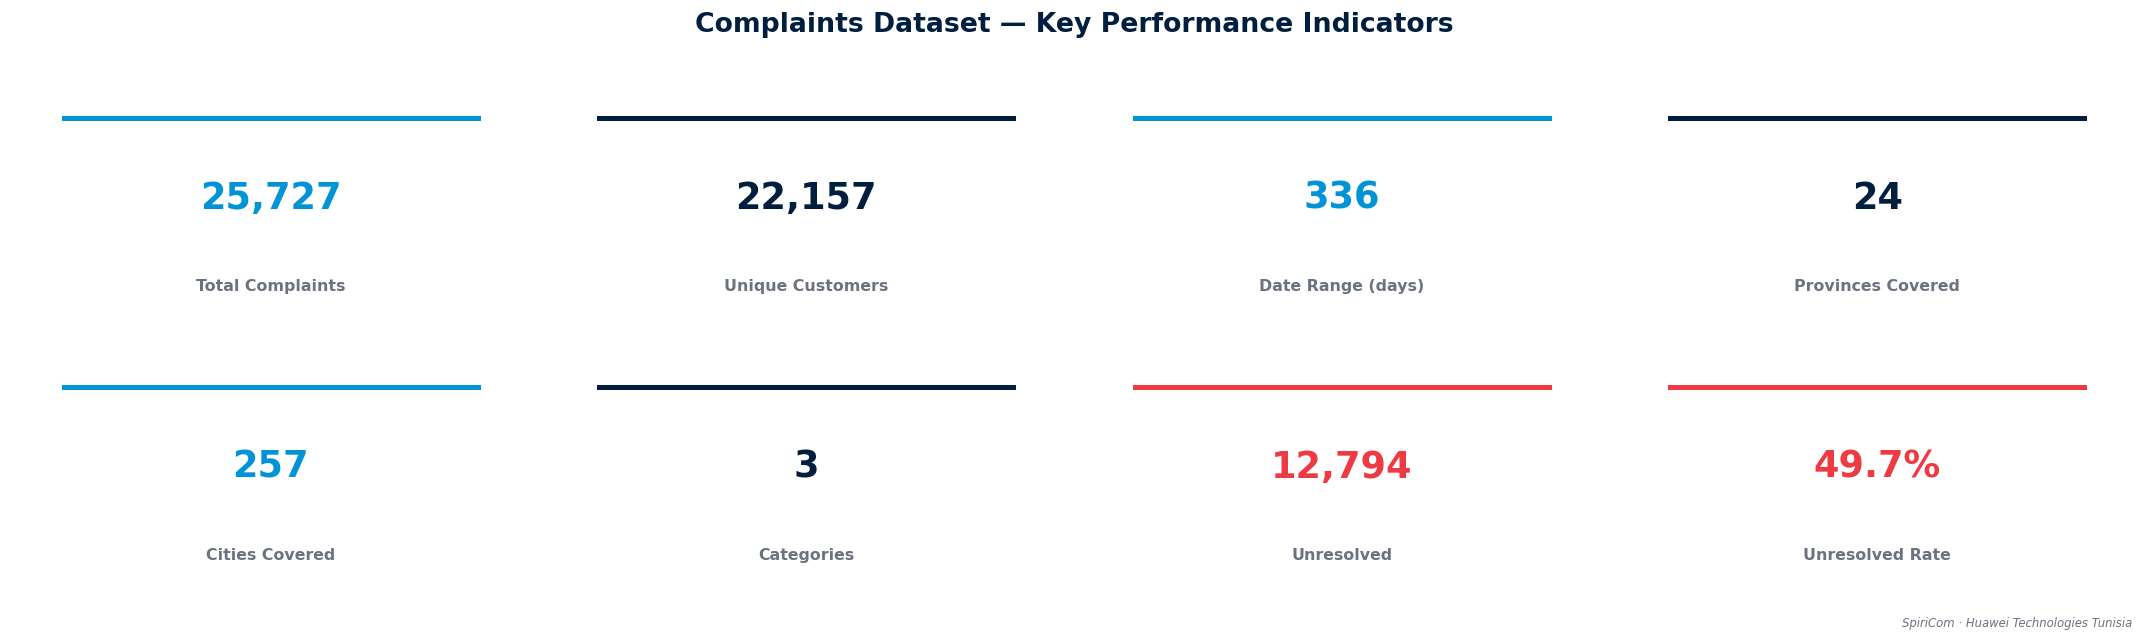


  Date range: 2025-01-01 → 2025-12-03


In [3]:
# ── 1.2  KPI tiles ────────────────────────────────────────────────────
total        = len(df)
date_min     = df['opened_at'].min()
date_max     = df['opened_at'].max()
date_range   = (date_max - date_min).days
unique_msisdn= df['msisdn'].nunique()
n_provinces  = df['province'].nunique()  if 'province'  in df.columns else 0
n_cities     = df['city'].nunique()      if 'city'      in df.columns else 0
n_categories = df['category'].nunique()  if 'category'  in df.columns else 0
unresolved   = df['is_unresolved'].sum() if 'is_unresolved' in df.columns else 0
unresolved_pct = unresolved / total * 100

kpis = [
    ('Total Complaints',    f'{total:,}',             HW['blue']),
    ('Unique Customers',    f'{unique_msisdn:,}',     HW['navy']),
    ('Date Range (days)',   f'{date_range:,}',        HW['blue']),
    ('Provinces Covered',  f'{n_provinces}',          HW['navy']),
    ('Cities Covered',     f'{n_cities}',             HW['blue']),
    ('Categories',         f'{n_categories}',         HW['navy']),
    ('Unresolved',         f'{unresolved:,}',         HW['red']),
    ('Unresolved Rate',    f'{unresolved_pct:.1f}%',  HW['red']),
]

fig, axes = plt.subplots(2, 4, figsize=(18, 5))
fig.suptitle('Complaints Dataset — Key Performance Indicators',
             fontsize=16, fontweight='bold', color=HW['navy'], y=1.04)

for ax, (label, value, color) in zip(axes.flat, kpis):
    ax.set_facecolor('#F8FAFC')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.axis('off')
    # Accent line top
    ax.axhline(y=0.92, xmin=0.1, xmax=0.9, color=color, linewidth=3)
    ax.text(0.5, 0.6,  value, ha='center', va='center',
            fontsize=22, fontweight='bold', color=color)
    ax.text(0.5, 0.25, label, ha='center', va='center',
            fontsize=9.5, color=HW['muted'], fontweight='bold')
    # Border
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor('#E5E7EB')
        spine.set_linewidth(1)

add_watermark(fig)
plt.tight_layout()
save_fig(fig, 'fig01_kpi_tiles')
plt.show()

print(f'\n  Date range: {date_min.date()} → {date_max.date()}')

> **Insight:** This section establishes the scope of the dataset. The unresolved rate is a key business metric tracked by the NOC team.

---
##  Section 2 — Time Series Analysis
Daily, weekly, and monthly complaint volumes to identify trends and seasonal patterns.

  Saved: data\outputs\figures\fig02_daily_trend.png


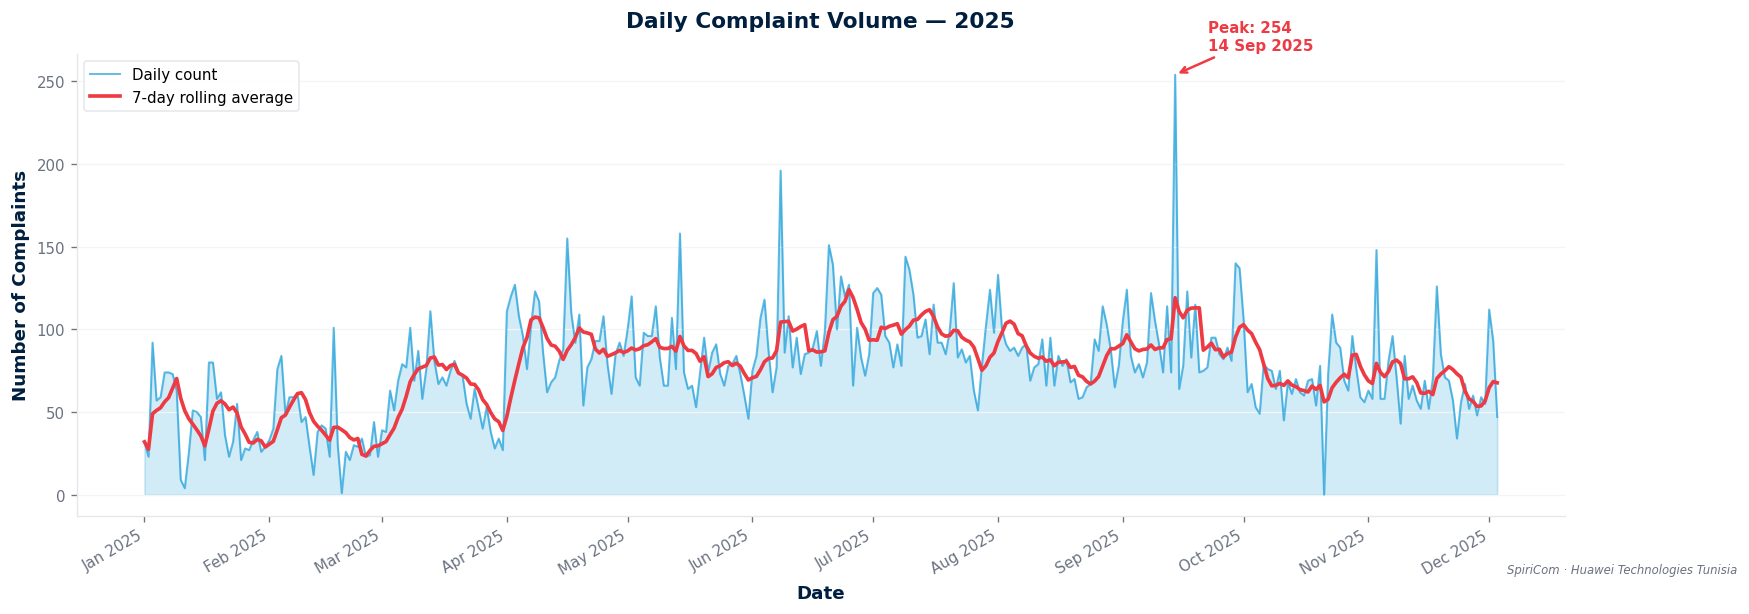

In [4]:
# ── 2.1  Daily trend with 7-day rolling average ───────────────────────
daily = df.set_index('opened_at').resample('D').size().rename('count').reset_index()
daily['roll7'] = daily['count'].rolling(7, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(16, 5))
ax.fill_between(daily['opened_at'], daily['count'],
                alpha=0.18, color=HW['blue'])
ax.plot(daily['opened_at'], daily['count'],
        color=HW['blue'], linewidth=1.2, alpha=0.6, label='Daily count')
ax.plot(daily['opened_at'], daily['roll7'],
        color=HW['red'], linewidth=2.2, label='7-day rolling average')

# Annotate peak day
peak_idx = daily['count'].idxmax()
peak_row = daily.loc[peak_idx]
ax.annotate(f"Peak: {int(peak_row['count'])}\n{peak_row['opened_at'].strftime('%d %b %Y')}",
            xy=(peak_row['opened_at'], peak_row['count']),
            xytext=(20, 15), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color=HW['red'], lw=1.5),
            fontsize=9, color=HW['red'], fontweight='bold')

ax.set_title('Daily Complaint Volume — 2025', pad=16)
ax.set_xlabel('Date')
ax.set_ylabel('Number of Complaints')
ax.legend(loc='upper left')
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(plt.matplotlib.dates.MonthLocator())
plt.xticks(rotation=30, ha='right')

add_watermark(fig)
save_fig(fig, 'fig02_daily_trend')
plt.show()

  Saved: data\outputs\figures\fig03_monthly_trend.png


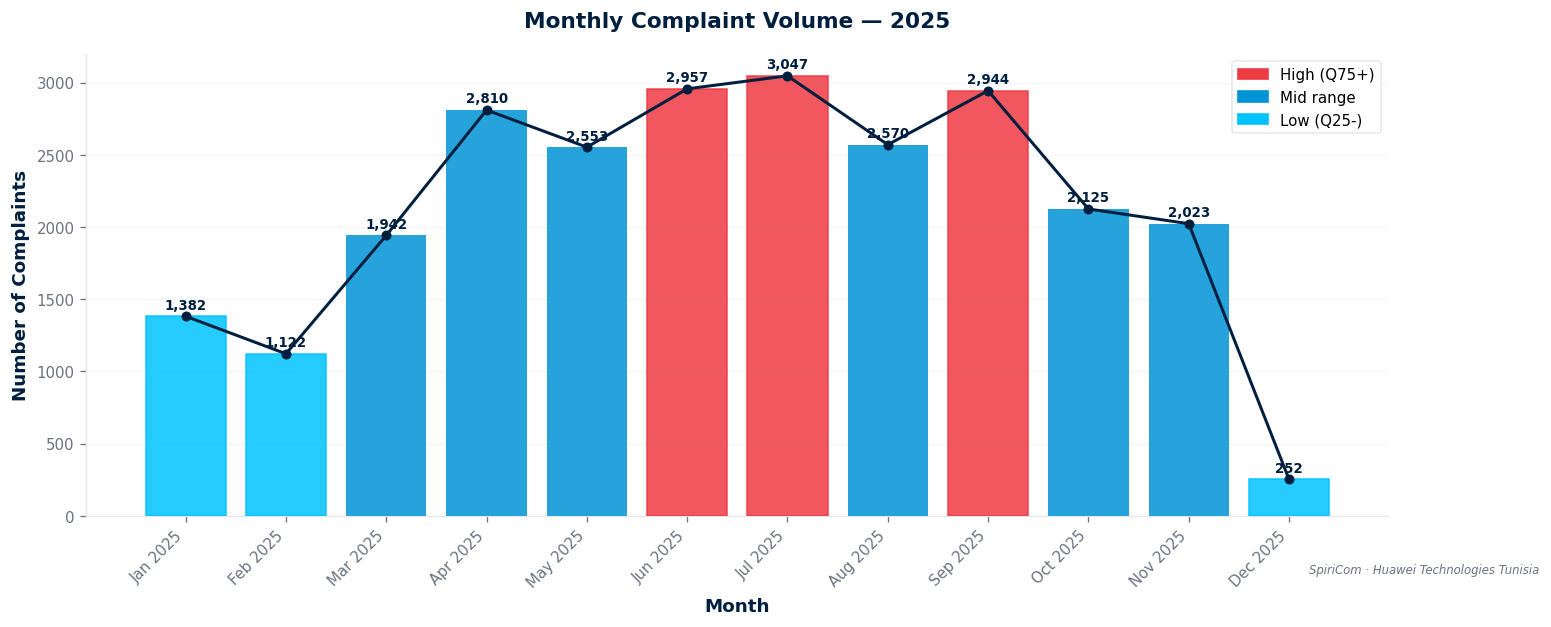

In [5]:
# ── 2.2  Monthly bar + line overlay ──────────────────────────────────
monthly = df.set_index('opened_at').resample('M').size().rename('count').reset_index()
monthly['month_label'] = monthly['opened_at'].dt.strftime('%b %Y')

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(monthly['month_label'], monthly['count'],
              color=HW['blue'], alpha=0.85, zorder=3)

# Color bars by quartile for visual clarity
q75 = monthly['count'].quantile(0.75)
q25 = monthly['count'].quantile(0.25)
for bar, val in zip(bars, monthly['count']):
    if val >= q75:
        bar.set_color(HW['red'])
    elif val <= q25:
        bar.set_color(HW['cyan'])

ax.plot(monthly['month_label'], monthly['count'],
        color=HW['navy'], linewidth=1.8, marker='o',
        markersize=5, zorder=4, label='Monthly trend')

# Value labels on top of bars
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(monthly['count']) * 0.01,
            f'{int(bar.get_height()):,}', ha='center', va='bottom',
            fontsize=8, color=HW['navy'], fontweight='bold')

legend_patches = [
    mpatches.Patch(color=HW['red'],  label='High (Q75+)'),
    mpatches.Patch(color=HW['blue'], label='Mid range'),
    mpatches.Patch(color=HW['cyan'], label='Low (Q25-)'),
]
ax.legend(handles=legend_patches, loc='upper right')
ax.set_title('Monthly Complaint Volume — 2025', pad=16)
ax.set_xlabel('Month')
ax.set_ylabel('Number of Complaints')
plt.xticks(rotation=45, ha='right')

add_watermark(fig)
save_fig(fig, 'fig03_monthly_trend')
plt.show()

  Saved: data\outputs\figures\fig04_weekly_heatmap.png


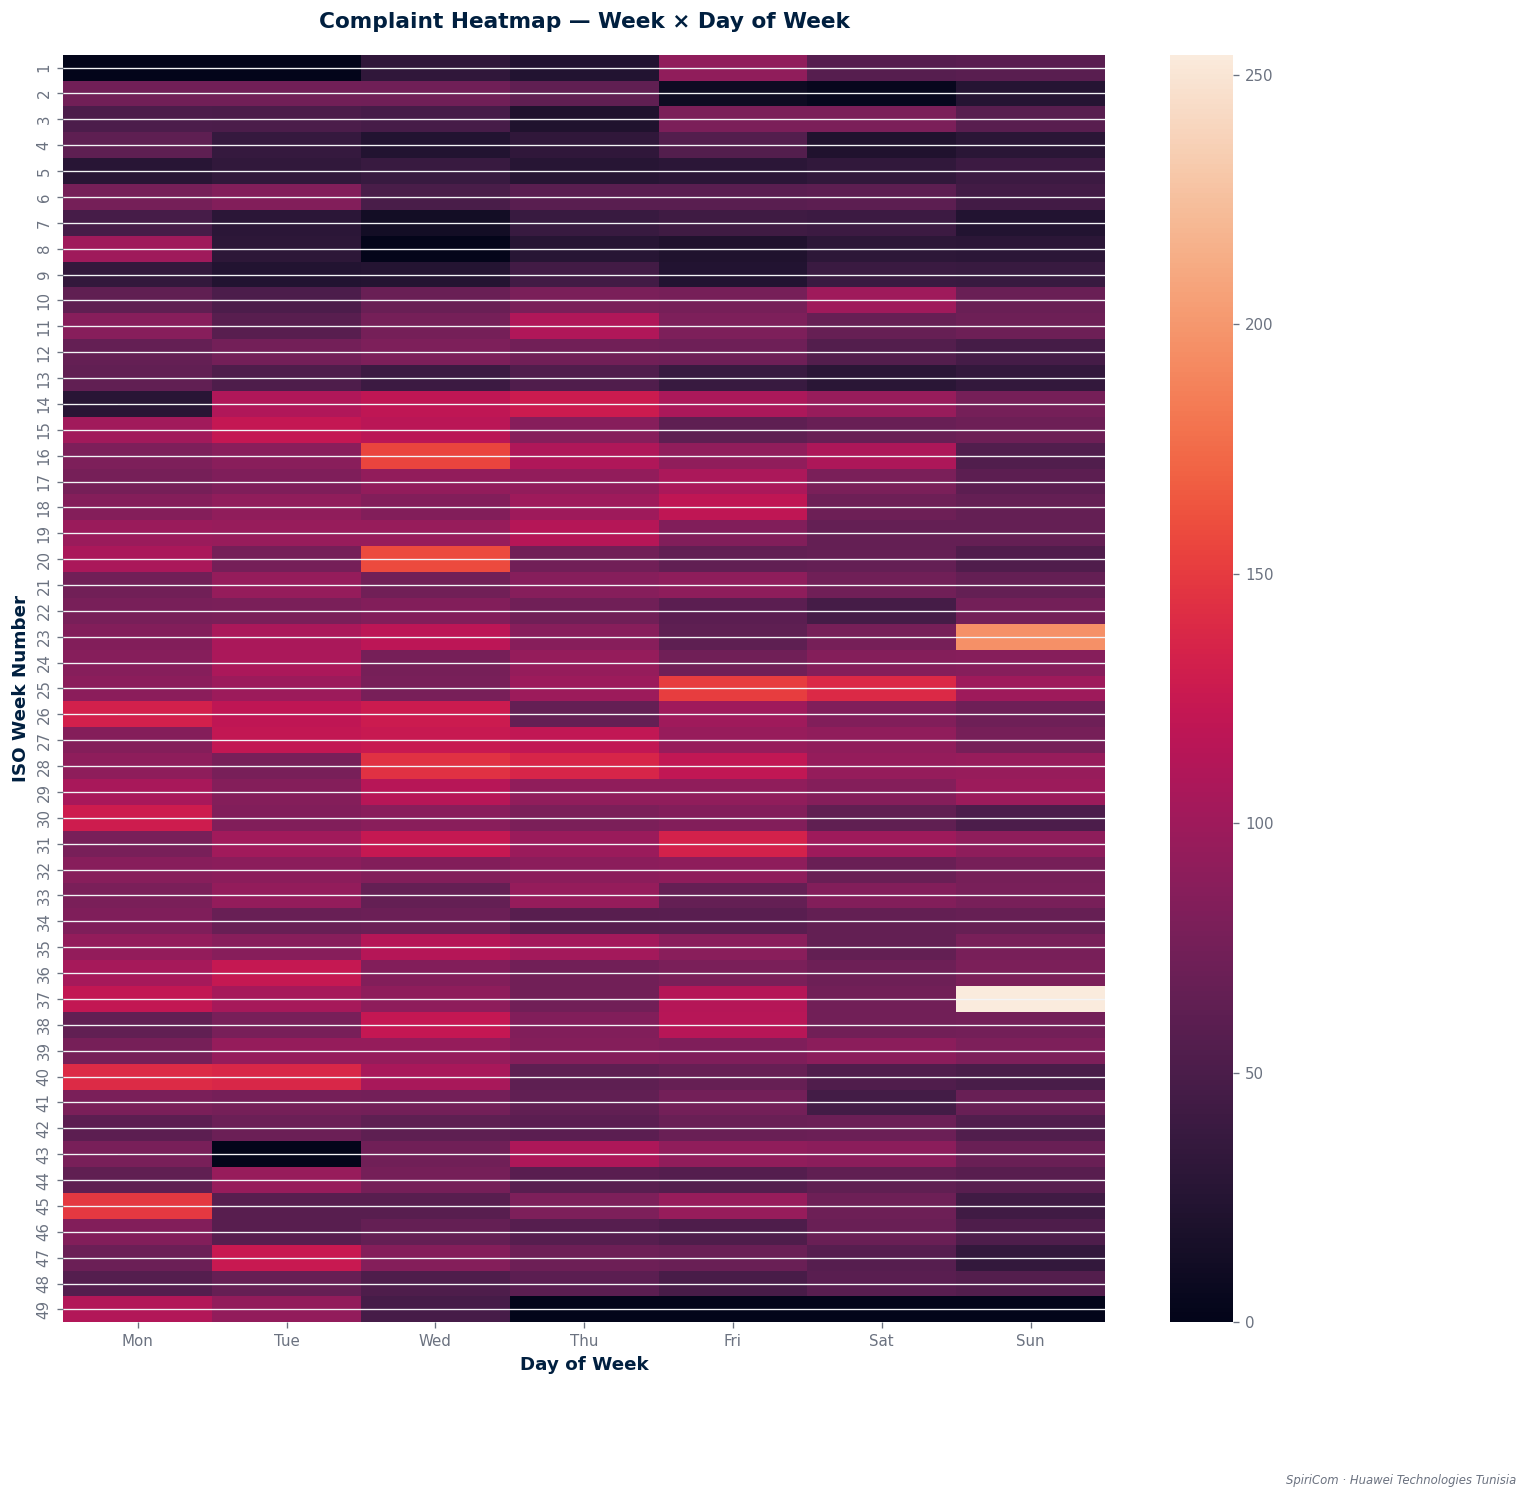

In [6]:
# ── 2.3 Weekly trend (heatmap: week × day-of-week) ──────────────────
df_ts = df.copy()
df_ts['dow']  = df_ts['opened_at'].dt.dayofweek
df_ts['week'] = df_ts['opened_at'].dt.isocalendar().week.astype(int)

pivot = df_ts.pivot_table(index='week', columns='dow',
                          values='case_id', aggfunc='count', fill_value=0)
pivot.columns = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun'][:len(pivot.columns)]

fig, ax = plt.subplots(figsize=(14, max(5, len(pivot) * 0.28)))

cmap = mcolors.LinearSegmentedColormap.from_list(
    'hw', ['#EFF6FF', '#0093D5', '#001F3F'])

# Fix: Use boolean for annot parameter
max_val = pivot.values.max()
show_annot = max_val < 200  # Show numbers only if max < 200
should_annotate = int(pivot.values.max()) < 200 and len(pivot) <= 30
annot_data = pivot if should_annotate else False
fmt_str    = 'd'   if should_annotate else ''
sns.heatmap(pivot, annot=annot_data, fmt=fmt_str)


ax.set_title('Complaint Heatmap — Week × Day of Week', pad=16)
ax.set_xlabel('Day of Week')
ax.set_ylabel('ISO Week Number')

add_watermark(fig)
save_fig(fig, 'fig04_weekly_heatmap')
plt.show()

  Saved: data\outputs\figures\fig05_dow_distribution.png


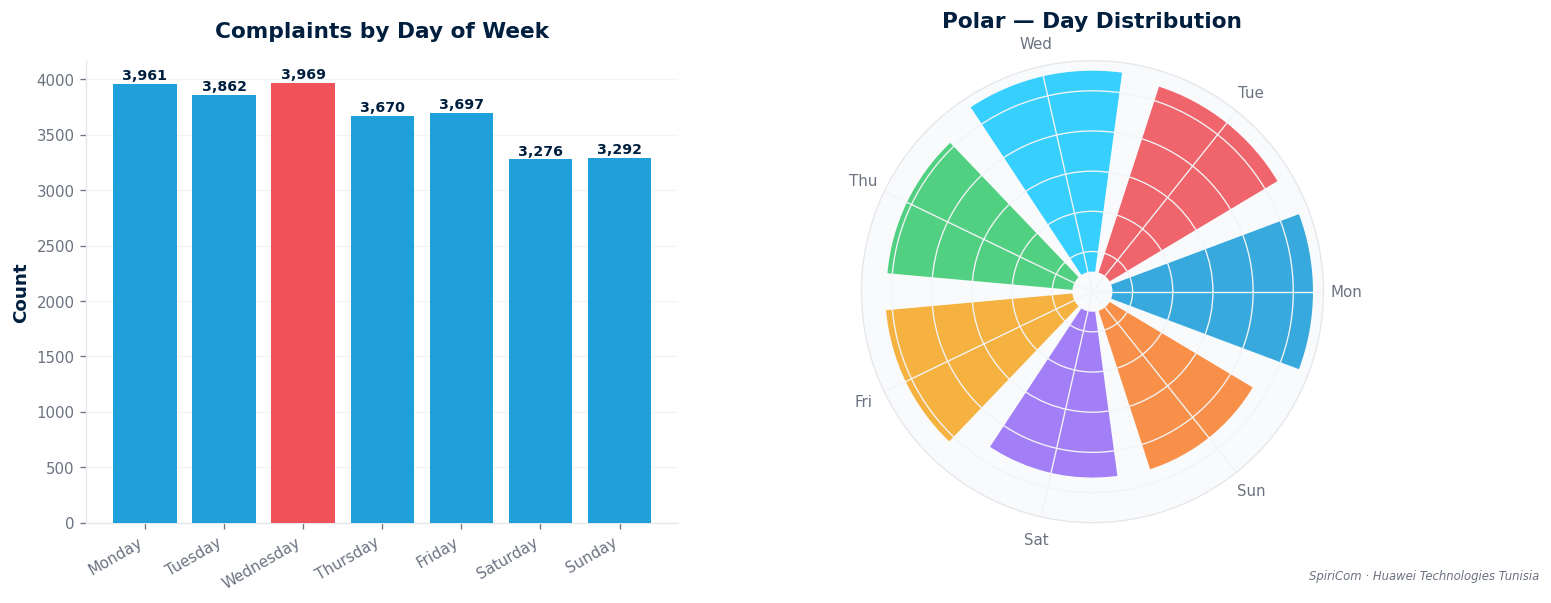

In [7]:
# ── 2.4  Day-of-week distribution ────────────────────────────────────
dow_labels = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_counts = df['opened_at'].dt.dayofweek.value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
ax = axes[0]
colors_dow = [HW['red'] if dow_counts.get(i,0) == dow_counts.max()
              else HW['blue'] for i in range(7)]
ax.bar([dow_labels[i] for i in dow_counts.index],
       dow_counts.values, color=colors_dow, alpha=0.88, zorder=3)
for i, v in zip(dow_counts.index, dow_counts.values):
    ax.text(list(dow_counts.index).index(i), v + dow_counts.max() * 0.01,
            f'{v:,}', ha='center', fontsize=8.5,
            fontweight='bold', color=HW['navy'])
ax.set_title('Complaints by Day of Week', pad=14)
ax.set_ylabel('Count')
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

# Polar chart
ax2 = axes[1]
ax2.remove()
ax_polar = fig.add_subplot(1, 2, 2, projection='polar')
theta = np.linspace(0, 2 * np.pi, 8)[:-1]
radii = [dow_counts.get(i, 0) for i in range(7)]
radii_norm = np.array(radii) / max(radii)
bars_polar = ax_polar.bar(theta, radii_norm, width=2*np.pi/7 * 0.8,
                           color=PALETTE[:7], alpha=0.78, bottom=0.1)
ax_polar.set_xticks(theta)
ax_polar.set_xticklabels([d[:3] for d in dow_labels], fontsize=9)
ax_polar.set_yticklabels([])
ax_polar.set_title('Polar — Day Distribution', pad=20, fontweight='bold',
                    color=HW['navy'])
ax_polar.set_facecolor('#F8FAFC')
fig.patch.set_facecolor('white')

add_watermark(fig)
save_fig(fig, 'fig05_dow_distribution')
plt.show()

> **Conclusion — Time Series:**  
> The daily trend reveals whether complaint volumes are growing, stable, or declining. The day-of-week analysis identifies operational pressure points (e.g., Monday spikes after weekend incidents). Monthly peaks should align with known network events or seasonal patterns.

---
##  Section 3 — Geographic Distribution
Complaint concentration by province and city. High-complaint zones indicate network stress or service gaps.

  Saved: data\outputs\figures\fig06_province_ranking.png


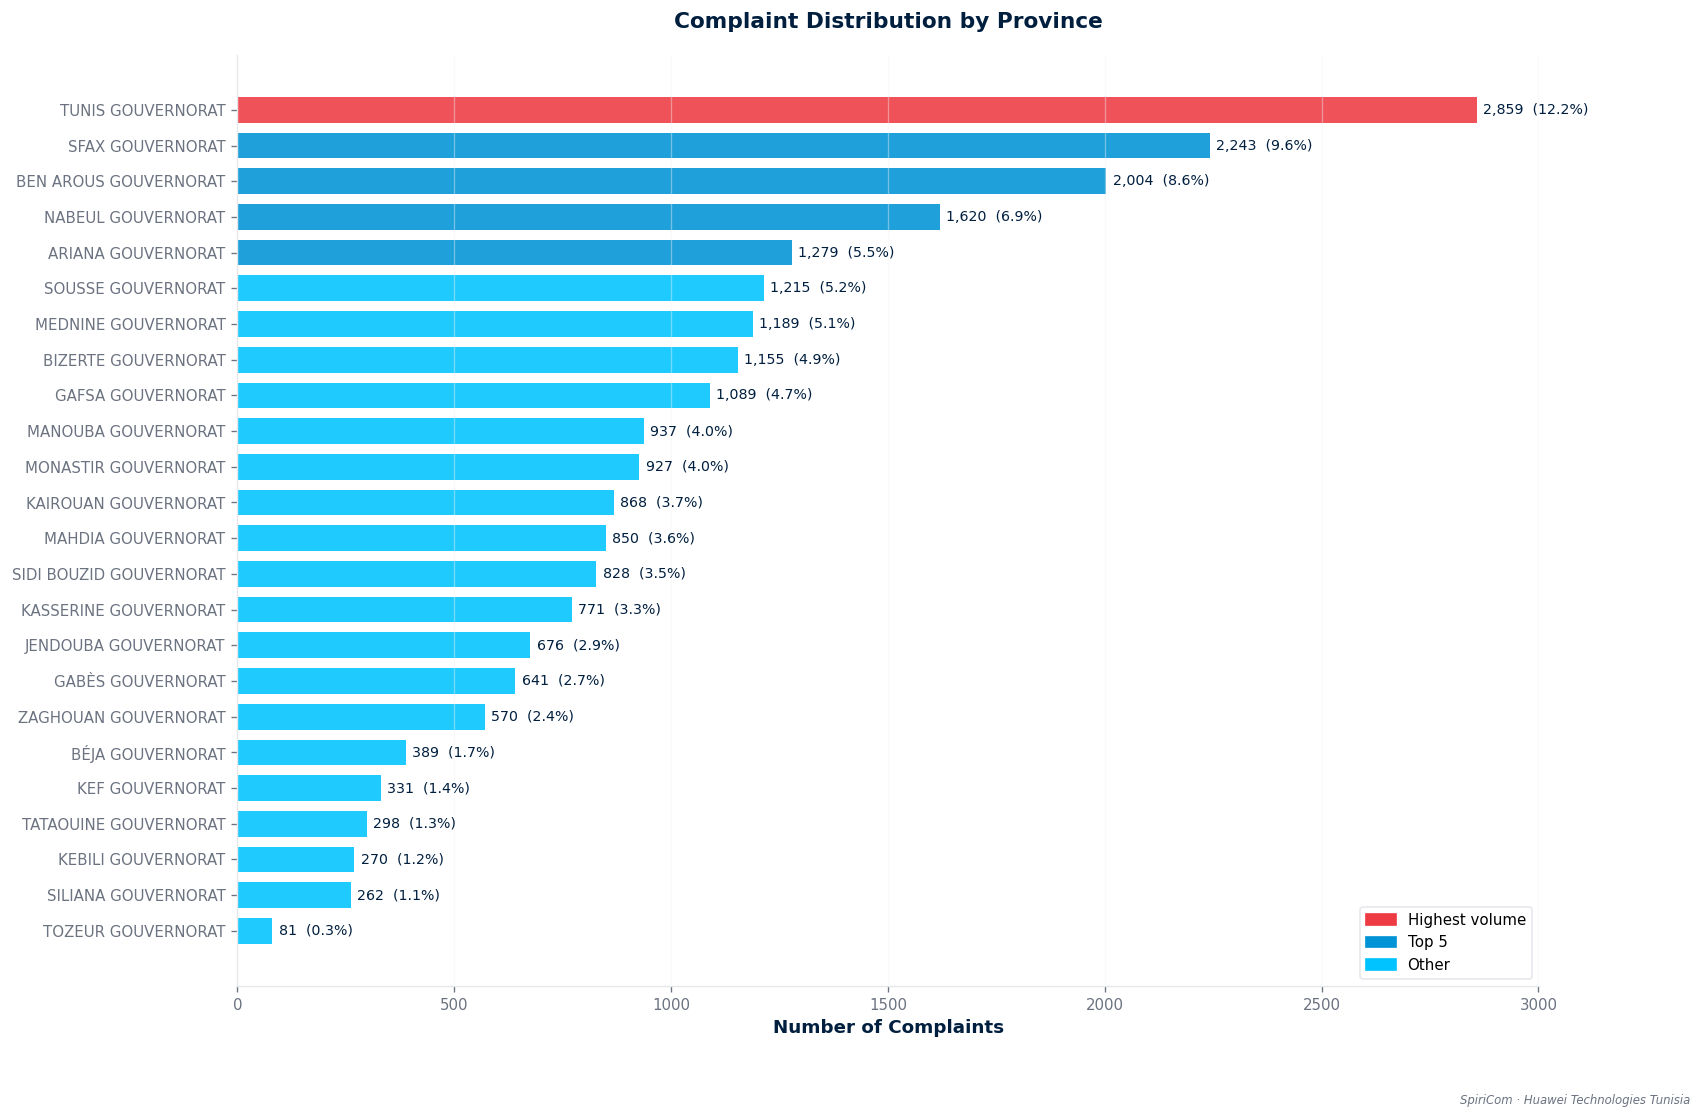

Top 5 provinces:
                province  count   pct
0      TUNIS GOUVERNORAT   2859  12.2
1       SFAX GOUVERNORAT   2243   9.6
2  BEN AROUS GOUVERNORAT   2004   8.6
3     NABEUL GOUVERNORAT   1620   6.9
4     ARIANA GOUVERNORAT   1279   5.5


In [8]:
# ── 3.1  Province ranking ─────────────────────────────────────────────
if 'province' in df.columns:
    prov = (df['province'].dropna()
               .value_counts()
               .reset_index()
               .rename(columns={'index': 'province', 'province': 'count'}))
    # Pandas 2.x rename
    prov.columns = ['province', 'count']
    prov['pct'] = (prov['count'] / prov['count'].sum() * 100).round(1)

    fig, ax = plt.subplots(figsize=(14, max(6, len(prov) * 0.42)))

    colors_prov = [
        HW['red']  if i == 0 else
        HW['blue'] if i < 5  else
        HW['cyan']
        for i in range(len(prov))
    ]
    bars = ax.barh(prov['province'][::-1], prov['count'][::-1],
                   color=colors_prov[::-1], alpha=0.88, height=0.72)

    for bar, pct_val in zip(bars, prov['pct'][::-1]):
        ax.text(bar.get_width() + prov['count'].max() * 0.005,
                bar.get_y() + bar.get_height() / 2,
                f'{int(bar.get_width()):,}  ({pct_val}%)',
                va='center', fontsize=8.5, color=HW['navy'])

    ax.set_title('Complaint Distribution by Province', pad=16)
    ax.set_xlabel('Number of Complaints')
    ax.grid(axis='x', alpha=0.4)
    ax.grid(axis='y', visible=False)
    legend_p = [
        mpatches.Patch(color=HW['red'],  label='Highest volume'),
        mpatches.Patch(color=HW['blue'], label='Top 5'),
        mpatches.Patch(color=HW['cyan'], label='Other'),
    ]
    ax.legend(handles=legend_p, loc='lower right')

    add_watermark(fig)
    save_fig(fig, 'fig06_province_ranking')
    plt.show()
    print('Top 5 provinces:')
    print(prov.head())
else:
    print('No province column found')

  Saved: data\outputs\figures\fig07_city_ranking.png


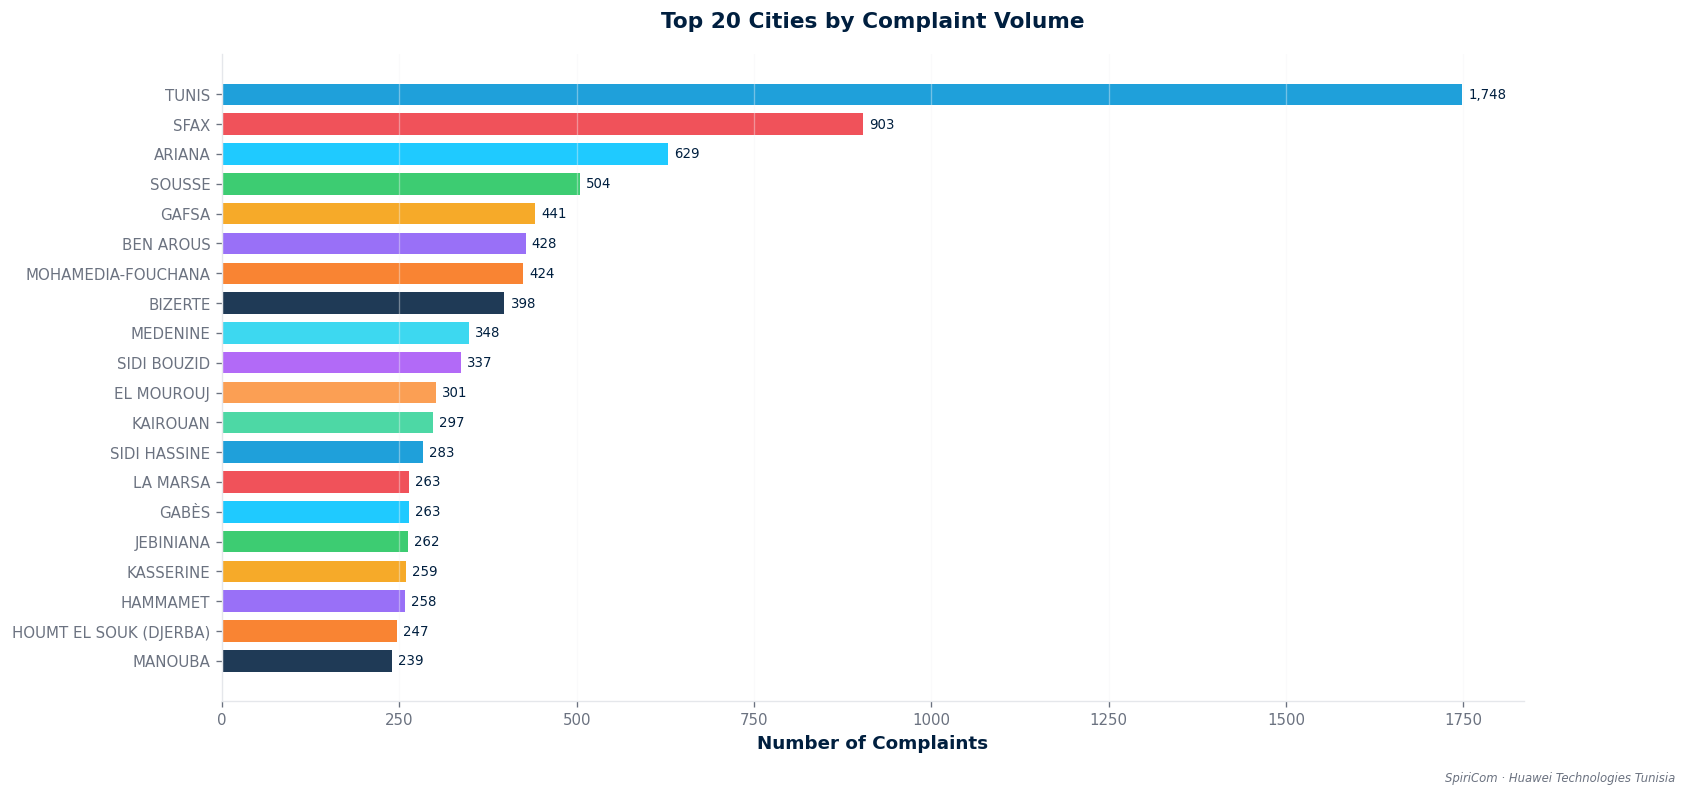

In [9]:
# ── 3.2  Top-20 cities ────────────────────────────────────────────────
if 'city' in df.columns:
    city = (df['city'].dropna()
               .value_counts()
               .head(20)
               .reset_index())
    city.columns = ['city', 'count']
    city['pct'] = (city['count'] / len(df) * 100).round(1)

    fig, ax = plt.subplots(figsize=(14, 7))
    bar_colors = [PALETTE[i % len(PALETTE)] for i in range(len(city))]
    ax.barh(city['city'][::-1], city['count'][::-1],
            color=bar_colors[::-1], alpha=0.88, height=0.72)

    for i, (_, row) in enumerate(city[::-1].iterrows()):
        ax.text(row['count'] + city['count'].max() * 0.005,
                i, f"{row['count']:,}",
                va='center', fontsize=8, color=HW['navy'])

    ax.set_title('Top 20 Cities by Complaint Volume', pad=16)
    ax.set_xlabel('Number of Complaints')
    ax.grid(axis='x', alpha=0.4)
    ax.grid(axis='y', visible=False)

    add_watermark(fig)
    save_fig(fig, 'fig07_city_ranking')
    plt.show()

In [10]:
# ── 3.3  Interactive treemap (Plotly) — Province > City ───────────────
if 'province' in df.columns and 'city' in df.columns:
    geo_df = (df.dropna(subset=['province','city'])
                .groupby(['province','city'])
                .size()
                .reset_index(name='count'))

    fig_tree = px.treemap(
        geo_df,
        path      = [px.Constant('Tunisia'), 'province', 'city'],
        values    = 'count',
        color     = 'count',
        color_continuous_scale = [
            [0.0, '#EFF6FF'], [0.3, '#0093D5'],
            [0.7, '#001F3F'], [1.0, '#EE3A43']
        ],
        title     = 'Geographic Complaint Distribution — Province → City',
        hover_data= {'count': True},
    )
    fig_tree.update_traces(textinfo='label+value+percent parent')
    fig_tree.update_layout(**PLOTLY_LAYOUT,
                            coloraxis_colorbar_title='Complaints')
    fig_tree.write_html(str(FIG_DIR / 'fig08_geo_treemap.html'))
    fig_tree.show()
    print('Interactive treemap saved as HTML')

Interactive treemap saved as HTML


  Saved: data\outputs\figures\fig09_province_month_heatmap.png


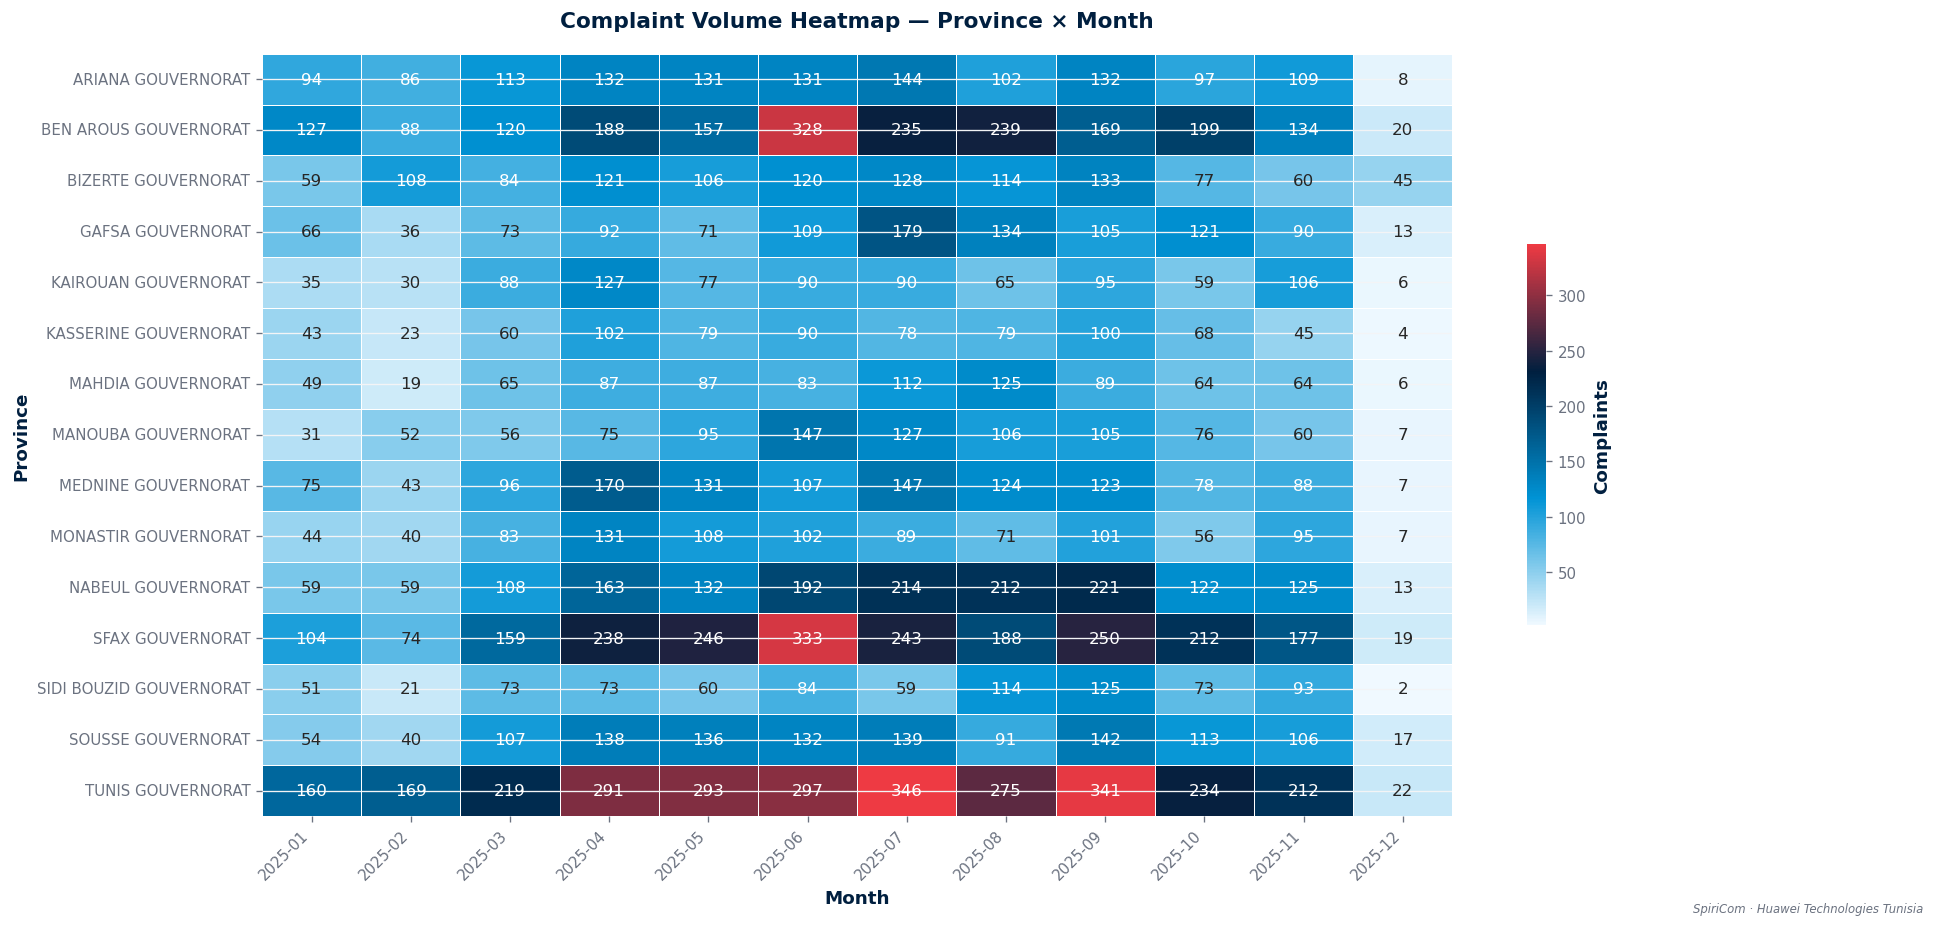

In [11]:
# ── 3.4  Province × Month heatmap ────────────────────────────────────
if 'province' in df.columns:
    df['month_label'] = df['opened_at'].dt.strftime('%Y-%m')
    prov_month = df.pivot_table(
        index='province', columns='month_label',
        values='case_id', aggfunc='count', fill_value=0)

    top15_prov = prov['province'].head(15).tolist()
    prov_month = prov_month.loc[prov_month.index.isin(top15_prov)]

    fig, ax = plt.subplots(figsize=(16, max(6, len(prov_month) * 0.55)))
    cmap2 = mcolors.LinearSegmentedColormap.from_list(
        'hw2', ['#F0F9FF','#0093D5','#001F3F','#EE3A43'])

    sns.heatmap(prov_month, ax=ax, cmap=cmap2,
                linewidths=0.5, linecolor='white',
                cbar_kws={'label': 'Complaints', 'shrink': 0.5},
                fmt='d',
                annot=bool(prov_month.values.max() < 500))   # ← bool() fix

    ax.set_title('Complaint Volume Heatmap — Province × Month', pad=16)
    ax.set_xlabel('Month')
    ax.set_ylabel('Province')
    plt.xticks(rotation=45, ha='right')

    add_watermark(fig)
    save_fig(fig, 'fig09_province_month_heatmap')
    plt.show()

> **Conclusion — Geographic:**  
> The province and city rankings directly guide network investment priorities. High-complaint provinces with high unresolved rates represent the most critical NOC intervention zones. The Province × Month heatmap reveals whether geographic patterns are consistent or episodic.

---
## 📊 Section 4 — Category & Sub-Category Analysis
Understanding complaint types guides root cause prioritization.

  Saved: data\outputs\figures\fig10_category_distribution.png


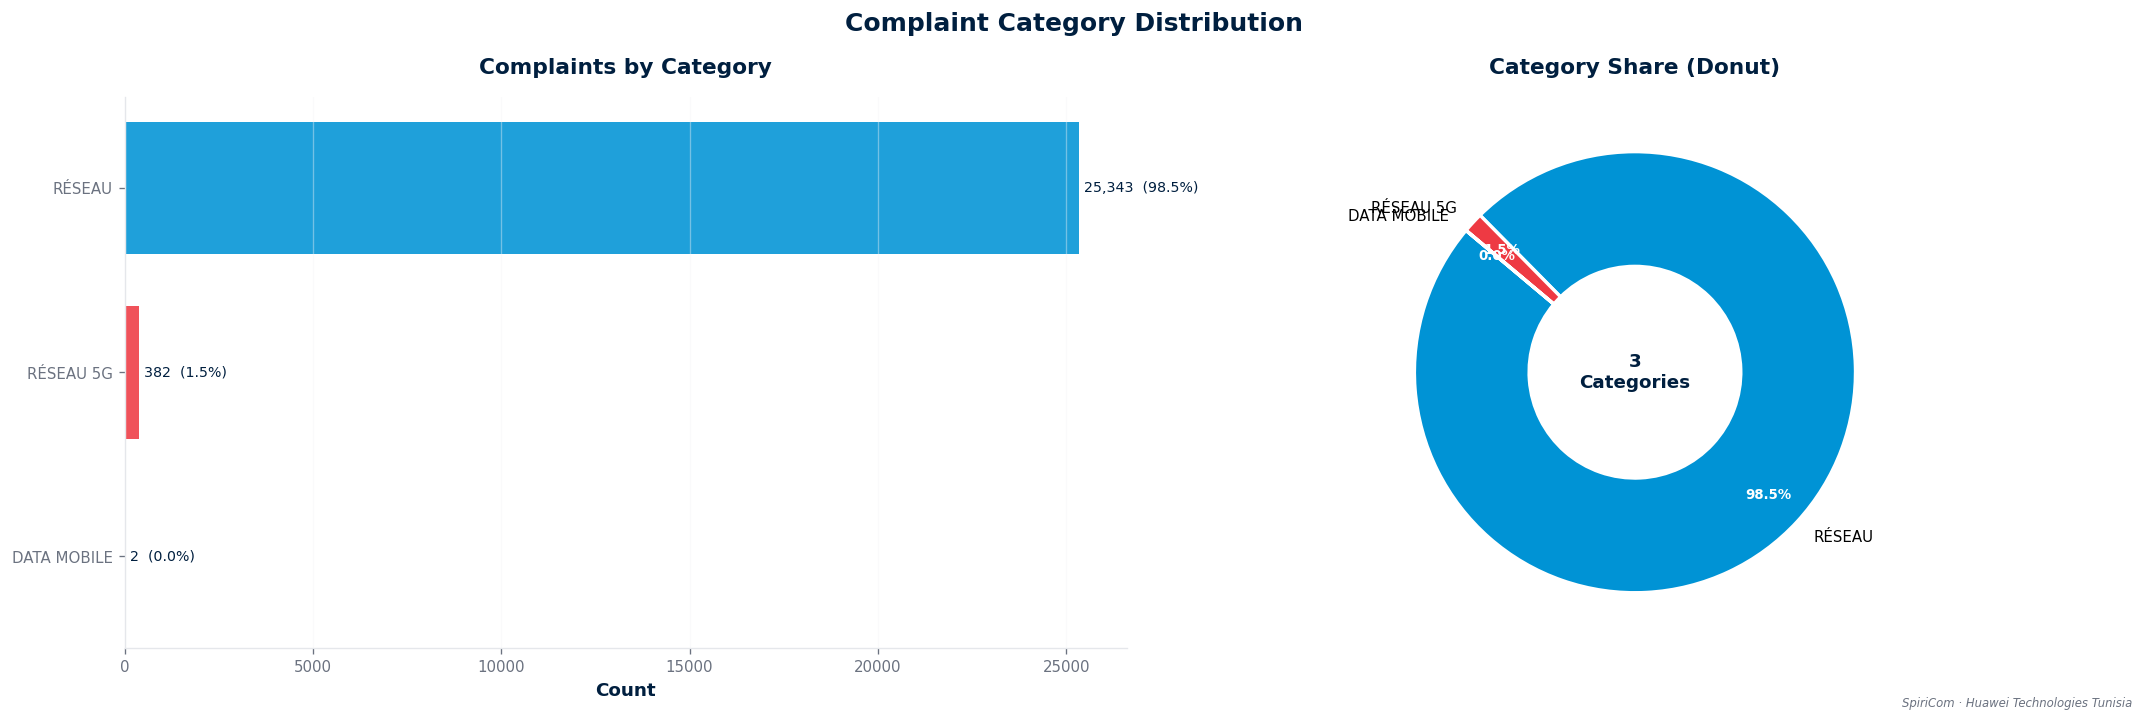

In [12]:
# ── 4.1  Category distribution ───────────────────────────────────────
if 'category' in df.columns:
    cat = (df['category'].dropna()
              .value_counts()
              .reset_index())
    cat.columns = ['category', 'count']
    cat['pct'] = (cat['count'] / cat['count'].sum() * 100).round(1)

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    # --- Left: horizontal bar ---
    ax = axes[0]
    colors_cat = [PALETTE[i % len(PALETTE)] for i in range(len(cat))]
    ax.barh(cat['category'][::-1], cat['count'][::-1],
            color=colors_cat[::-1], alpha=0.88, height=0.72)
    for i, (_, row) in enumerate(cat[::-1].iterrows()):
        ax.text(row['count'] + cat['count'].max() * 0.005, i,
                f"{row['count']:,}  ({row['pct']}%)",
                va='center', fontsize=8.5, color=HW['navy'])
    ax.set_title('Complaints by Category', pad=14)
    ax.set_xlabel('Count')
    ax.grid(axis='x', alpha=0.4)
    ax.grid(axis='y', visible=False)

    # --- Right: donut ---
    ax2 = axes[1]
    wedges, texts, autotexts = ax2.pie(
        cat['count'],
        labels=cat['category'],
        colors=colors_cat,
        autopct='%1.1f%%',
        startangle=140,
        pctdistance=0.82,
        wedgeprops=dict(width=0.52, edgecolor='white', linewidth=2),
    )
    for at in autotexts:
        at.set_fontsize(8)
        at.set_color('white')
        at.set_fontweight('bold')
    ax2.set_title('Category Share (Donut)', pad=14)
    ax2.text(0, 0, f'{len(cat)}\nCategories',
             ha='center', va='center', fontsize=11,
             fontweight='bold', color=HW['navy'])

    fig.suptitle('Complaint Category Distribution', fontsize=15,
                 fontweight='bold', color=HW['navy'])
    add_watermark(fig)
    plt.tight_layout()
    save_fig(fig, 'fig10_category_distribution')
    plt.show()

  Saved: data\outputs\figures\fig11_subcategory.png


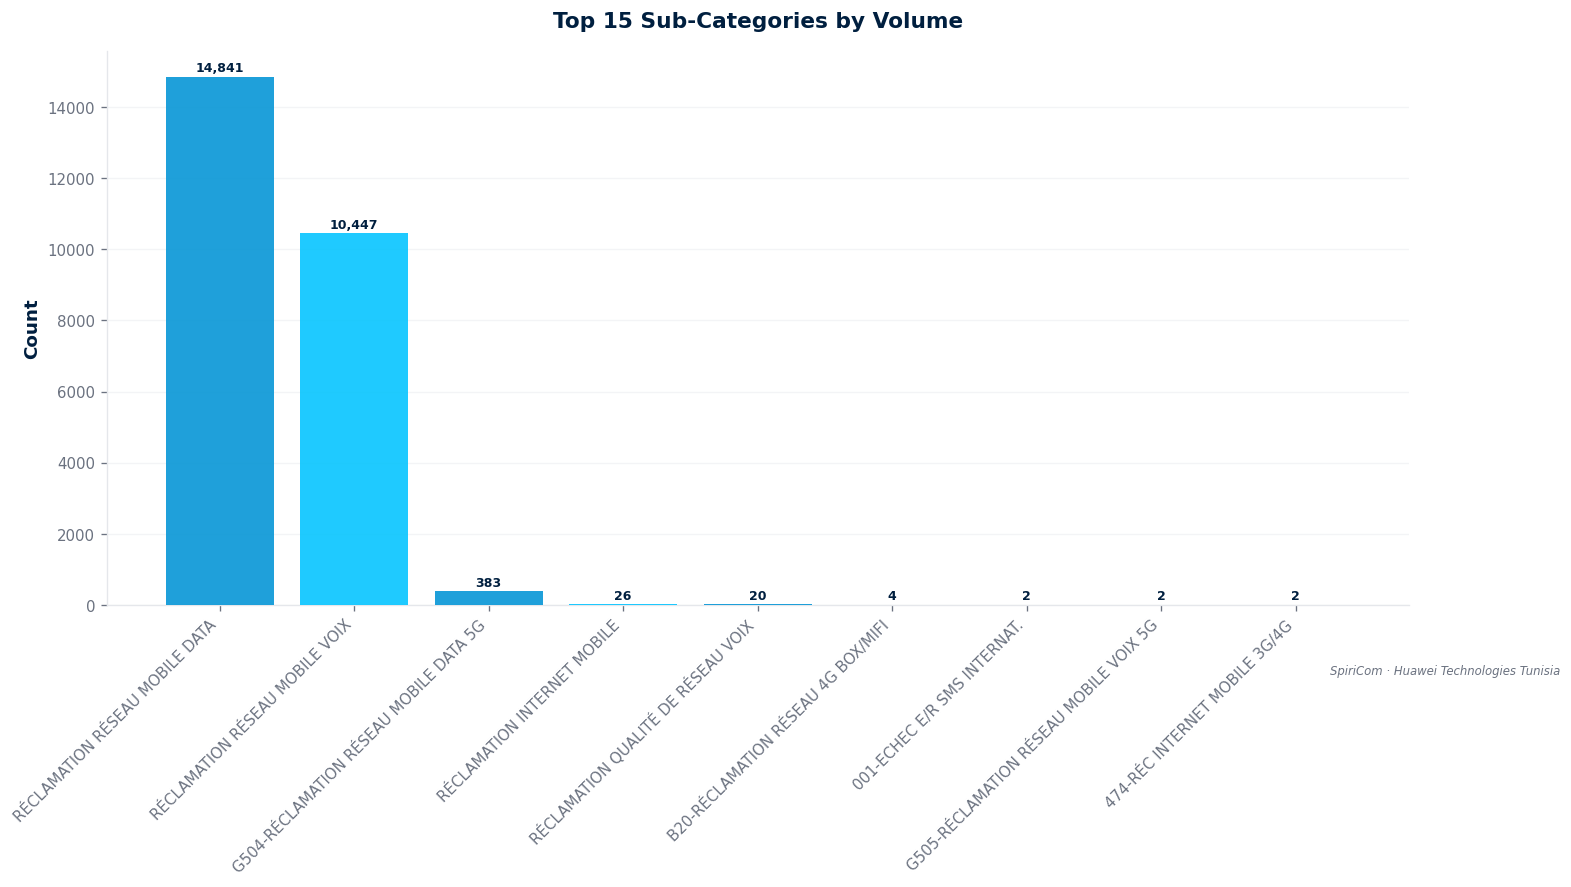

In [13]:
# ── 4.2  Sub-category (top 15) ────────────────────────────────────────
if 'sub_category' in df.columns:
    subcat = (df['sub_category'].dropna()
                 .value_counts()
                 .head(15)
                 .reset_index())
    subcat.columns = ['sub_category', 'count']

    fig, ax = plt.subplots(figsize=(14, 6))
    colors_sub = [HW['blue'] if i % 2 == 0 else HW['cyan']
                  for i in range(len(subcat))]
    bars = ax.bar(range(len(subcat)), subcat['count'],
                  color=colors_sub, alpha=0.88, zorder=3)

    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + subcat['count'].max() * 0.01,
                f'{int(bar.get_height()):,}',
                ha='center', fontsize=7.5, color=HW['navy'], fontweight='bold')

    ax.set_xticks(range(len(subcat)))
    ax.set_xticklabels(subcat['sub_category'], rotation=45, ha='right', fontsize=9)
    ax.set_title('Top 15 Sub-Categories by Volume', pad=14)
    ax.set_ylabel('Count')

    add_watermark(fig)
    save_fig(fig, 'fig11_subcategory')
    plt.show()

In [14]:
# ── 4.3  Interactive sunburst: Category > Sub-category ────────────────
if 'category' in df.columns and 'sub_category' in df.columns:
    sun_df = (df.dropna(subset=['category','sub_category'])
                .groupby(['category','sub_category'])
                .size()
                .reset_index(name='count'))

    fig_sun = px.sunburst(
        sun_df,
        path   = ['category','sub_category'],
        values = 'count',
        color  = 'count',
        color_continuous_scale = [
            [0, '#EFF6FF'], [0.4, '#0093D5'],
            [0.75, '#001F3F'], [1, '#EE3A43']
        ],
        title  = 'Complaint Hierarchy — Category > Sub-Category',
    )
    fig_sun.update_traces(textinfo='label+percent entry')
    fig_sun.update_layout(**PLOTLY_LAYOUT)
    fig_sun.write_html(str(FIG_DIR / 'fig12_category_sunburst.html'))
    fig_sun.show()
    print('Interactive sunburst saved as HTML')

Interactive sunburst saved as HTML


  Saved: data\outputs\figures\fig13_category_trend.png


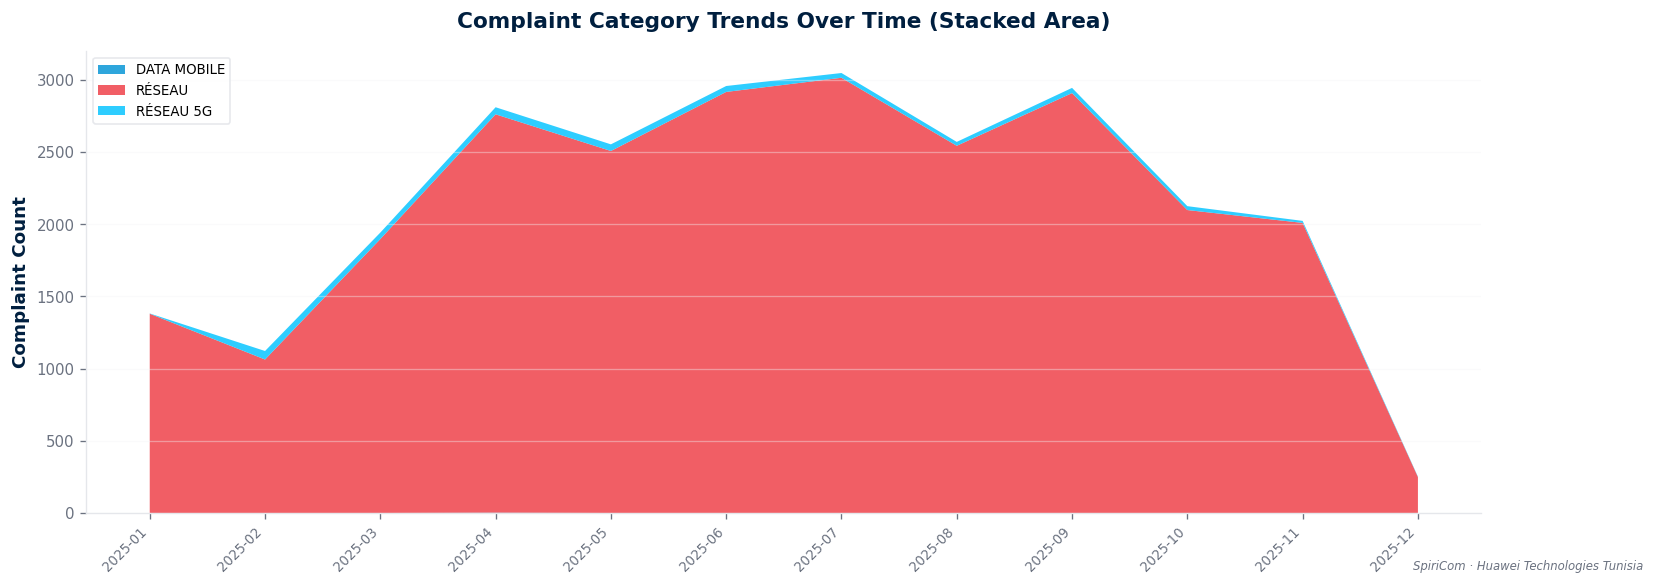

In [15]:
# ── 4.4  Category trend over time (stacked area) ─────────────────────
if 'category' in df.columns:
    top_cats = cat['category'].head(6).tolist()
    df_top   = df[df['category'].isin(top_cats)].copy()
    df_top['month_label'] = df_top['opened_at'].dt.to_period('M').astype(str)

    pivot_cat = df_top.pivot_table(
        index='month_label', columns='category',
        values='case_id', aggfunc='count', fill_value=0)

    fig, ax = plt.subplots(figsize=(15, 5))
    ax.stackplot(range(len(pivot_cat)),
                 [pivot_cat[c] for c in pivot_cat.columns],
                 labels=pivot_cat.columns,
                 colors=PALETTE[:len(pivot_cat.columns)],
                 alpha=0.82)

    ax.set_xticks(range(len(pivot_cat)))
    ax.set_xticklabels(pivot_cat.index, rotation=45, ha='right', fontsize=8)
    ax.set_title('Complaint Category Trends Over Time (Stacked Area)', pad=14)
    ax.set_ylabel('Complaint Count')
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(axis='y', alpha=0.4)

    add_watermark(fig)
    save_fig(fig, 'fig13_category_trend')
    plt.show()

> **Conclusion — Category Analysis:**  
> The category hierarchy reveals whether complaints are concentrated in a few types (Pareto pattern) or spread across many. The stacked area chart shows whether the mix is shifting over time — a growing category may indicate an emerging network issue.

---
## 📊 Section 5 — Provider Group Comparison
Identify which provider groups generate the most complaints and have the lowest resolution rates.

  Saved: data\outputs\figures\fig14_provider_group.png


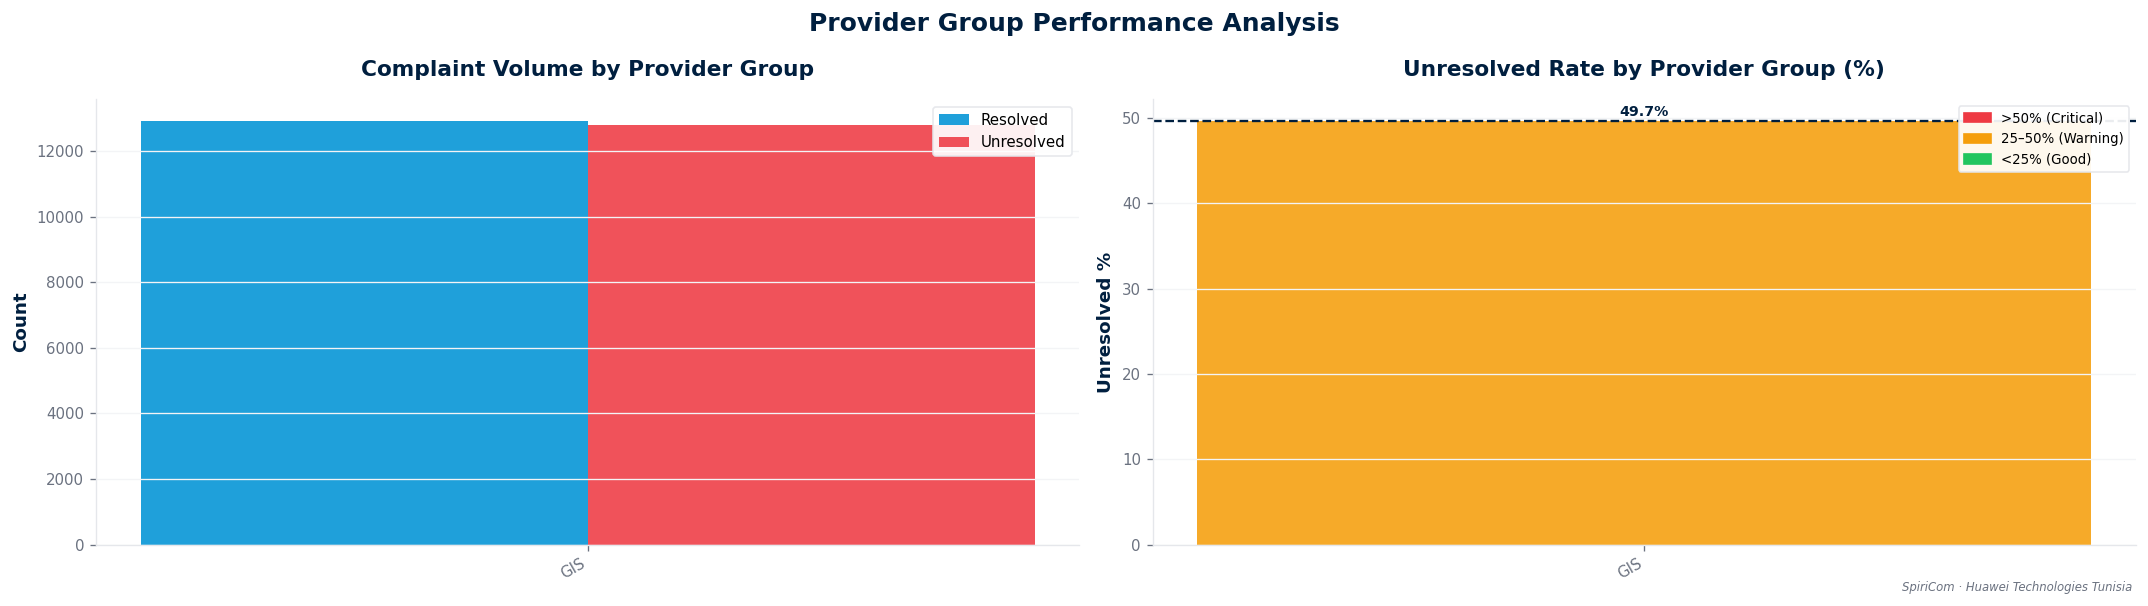

Provider Group Summary:
provider_group  total  unresolved  resolved  unresolved_pct
           GIS  25727       12794     12933            49.7


In [16]:
# ── 5.1  Provider group overview ─────────────────────────────────────
if 'provider_group' in df.columns:
    prov_grp = (df.groupby('provider_group')
                  .agg(
                      total       = ('case_id', 'count'),
                      unresolved  = ('is_unresolved', 'sum'),
                  ).reset_index())
    prov_grp['resolved']      = prov_grp['total'] - prov_grp['unresolved']
    prov_grp['unresolved_pct']= (prov_grp['unresolved'] / prov_grp['total'] * 100).round(1)
    prov_grp = prov_grp.sort_values('total', ascending=False)

    fig, axes = plt.subplots(1, 2, figsize=(18, 5))

    # Grouped bar: resolved vs unresolved
    ax = axes[0]
    x   = np.arange(len(prov_grp))
    w   = 0.38
    ax.bar(x - w/2, prov_grp['resolved'],   width=w, color=HW['blue'],  label='Resolved',   alpha=0.88)
    ax.bar(x + w/2, prov_grp['unresolved'], width=w, color=HW['red'],   label='Unresolved', alpha=0.88)
    ax.set_xticks(x)
    ax.set_xticklabels(prov_grp['provider_group'], rotation=30, ha='right', fontsize=9)
    ax.set_title('Complaint Volume by Provider Group', pad=14)
    ax.set_ylabel('Count')
    ax.legend()

    # Unresolved rate bar
    ax2 = axes[1]
    colors_rate = [
        HW['red']   if r > 50 else
        HW['amber'] if r > 25 else
        HW['green']
        for r in prov_grp['unresolved_pct']
    ]
    bars2 = ax2.bar(x, prov_grp['unresolved_pct'],
                    color=colors_rate, alpha=0.88)
    for bar, v in zip(bars2, prov_grp['unresolved_pct']):
        ax2.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5, f'{v}%',
                 ha='center', fontsize=8.5,
                 fontweight='bold', color=HW['navy'])
    ax2.axhline(prov_grp['unresolved_pct'].mean(),
                color=HW['navy'], linestyle='--',
                linewidth=1.4, label=f"Avg: {prov_grp['unresolved_pct'].mean():.1f}%")
    ax2.set_xticks(x)
    ax2.set_xticklabels(prov_grp['provider_group'], rotation=30, ha='right', fontsize=9)
    ax2.set_title('Unresolved Rate by Provider Group (%)', pad=14)
    ax2.set_ylabel('Unresolved %')
    ax2.legend()
    rate_legend = [
        mpatches.Patch(color=HW['red'],   label='>50% (Critical)'),
        mpatches.Patch(color=HW['amber'], label='25–50% (Warning)'),
        mpatches.Patch(color=HW['green'], label='<25% (Good)'),
    ]
    ax2.legend(handles=rate_legend, loc='upper right', fontsize=8)

    fig.suptitle('Provider Group Performance Analysis',
                 fontsize=15, fontweight='bold', color=HW['navy'])
    add_watermark(fig)
    plt.tight_layout()
    save_fig(fig, 'fig14_provider_group')
    plt.show()

    print('Provider Group Summary:')
    print(prov_grp.to_string(index=False))
else:
    print('No provider_group column found')

> **Conclusion — Provider Groups:**  
> Provider groups with high unresolved rates (>50%) require immediate escalation. The grouped bar chart allows direct comparison of raw volumes while the unresolved rate chart normalises for size, ensuring small-volume groups are not overlooked.

---
## ⏰ Section 6 — Resolution Analysis
Distribution of complaint statuses and resolution efficiency.

  Saved: data\outputs\figures\fig15_resolution_analysis.png


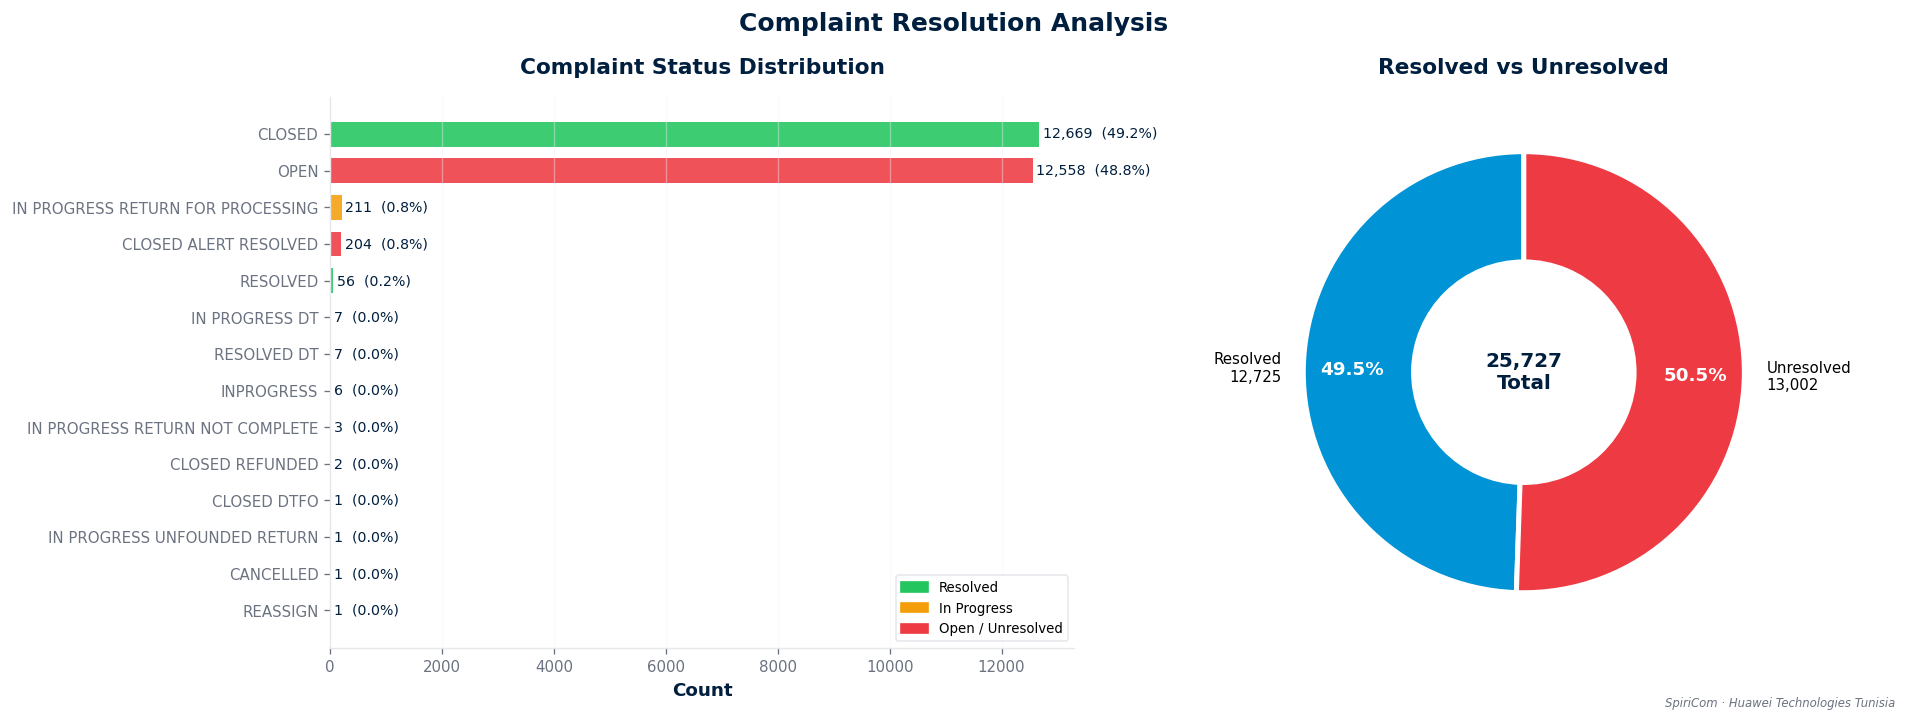

In [17]:
# ── 6.1  Status distribution ─────────────────────────────────────────
if 'status' in df.columns:
    status_counts = df['status'].value_counts().reset_index()
    status_counts.columns = ['status', 'count']
    status_counts['pct'] = (status_counts['count'] / len(df) * 100).round(1)

    # Colour by resolved / in-progress / unresolved
    RESOLVED_STATUSES = {'CLOSED','RESOLVED','FERME','CLOTURE','CLOSE','CLOS','RESOLU'}
    def status_color(s):
        if str(s).upper() in RESOLVED_STATUSES: return HW['green']
        if 'PROGRESS' in str(s).upper() or 'COURS' in str(s).upper(): return HW['amber']
        return HW['red']

    colors_status = [status_color(s) for s in status_counts['status']]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Bar chart
    ax = axes[0]
    bars = ax.barh(status_counts['status'][::-1],
                   status_counts['count'][::-1],
                   color=colors_status[::-1], alpha=0.88, height=0.68)
    for bar, pct_v in zip(bars, status_counts['pct'][::-1]):
        ax.text(bar.get_width() + status_counts['count'].max() * 0.005,
                bar.get_y() + bar.get_height() / 2,
                f"{int(bar.get_width()):,}  ({pct_v}%)",
                va='center', fontsize=8.5, color=HW['navy'])
    ax.set_title('Complaint Status Distribution', pad=14)
    ax.set_xlabel('Count')
    ax.grid(axis='x', alpha=0.4)
    ax.grid(axis='y', visible=False)
    legend_s = [
        mpatches.Patch(color=HW['green'], label='Resolved'),
        mpatches.Patch(color=HW['amber'], label='In Progress'),
        mpatches.Patch(color=HW['red'],   label='Open / Unresolved'),
    ]
    ax.legend(handles=legend_s, loc='lower right', fontsize=8)

    # Waterfall-style cumulative
    ax2 = axes[1]
    resolved_ct   = status_counts[status_counts['status'].str.upper().isin(RESOLVED_STATUSES)]['count'].sum()
    unresolved_ct = len(df) - resolved_ct
    wedge_data    = [resolved_ct, unresolved_ct]
    wedge_labels  = [f'Resolved\n{resolved_ct:,}', f'Unresolved\n{unresolved_ct:,}']
    wedge_colors  = [HW['blue'], HW['red']]
    wedges, texts, autotexts = ax2.pie(
        wedge_data, labels=wedge_labels, colors=wedge_colors,
        autopct='%1.1f%%', startangle=90, pctdistance=0.78,
        wedgeprops=dict(width=0.5, edgecolor='white', linewidth=3))
    for at in autotexts:
        at.set_fontsize(11); at.set_fontweight('bold'); at.set_color('white')
    ax2.text(0, 0, f'{len(df):,}\nTotal', ha='center', va='center',
             fontsize=12, fontweight='bold', color=HW['navy'])
    ax2.set_title('Resolved vs Unresolved', pad=14)

    fig.suptitle('Complaint Resolution Analysis',
                 fontsize=15, fontweight='bold', color=HW['navy'])
    add_watermark(fig)
    plt.tight_layout()
    save_fig(fig, 'fig15_resolution_analysis')
    plt.show()

  Saved: data\outputs\figures\fig16_unresolved_by_category.png


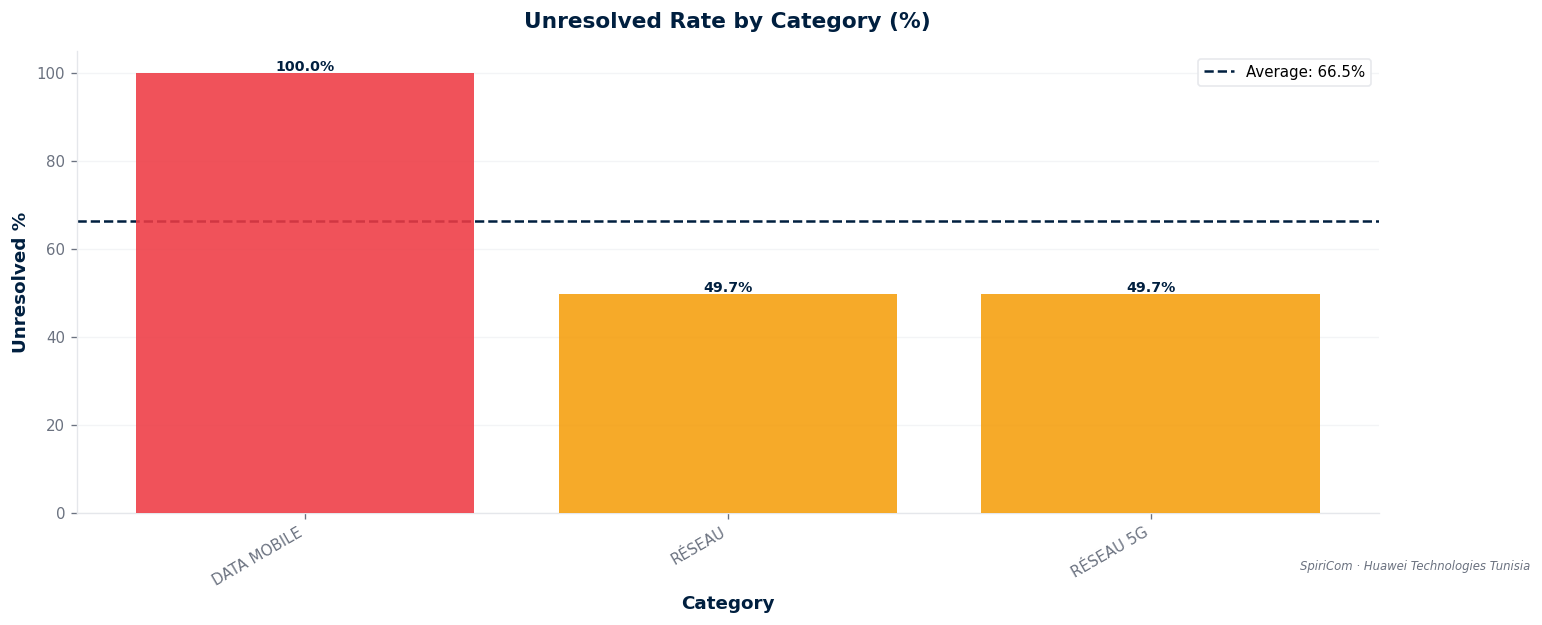

In [18]:
# ── 6.2  Unresolved rate by category ─────────────────────────────────
if 'category' in df.columns and 'is_unresolved' in df.columns:
    cat_res = (df.groupby('category')
                 .agg(total=('case_id','count'),
                      unresolved=('is_unresolved','sum'))
                 .reset_index())
    cat_res['rate'] = (cat_res['unresolved'] / cat_res['total'] * 100).round(1)
    cat_res = cat_res.sort_values('rate', ascending=False)

    fig, ax = plt.subplots(figsize=(14, 5))
    bar_colors = [
        HW['red']   if r > 60 else
        HW['amber'] if r > 30 else
        HW['green']
        for r in cat_res['rate']
    ]
    bars = ax.bar(cat_res['category'], cat_res['rate'],
                  color=bar_colors, alpha=0.88, zorder=3)
    ax.axhline(cat_res['rate'].mean(), color=HW['navy'],
               linestyle='--', linewidth=1.5,
               label=f"Average: {cat_res['rate'].mean():.1f}%")

    for bar, v in zip(bars, cat_res['rate']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{v}%', ha='center', fontsize=8.5,
                fontweight='bold', color=HW['navy'])

    ax.set_title('Unresolved Rate by Category (%)', pad=14)
    ax.set_ylabel('Unresolved %')
    ax.set_xlabel('Category')
    ax.legend()
    plt.xticks(rotation=30, ha='right')

    add_watermark(fig)
    save_fig(fig, 'fig16_unresolved_by_category')
    plt.show()

> **Conclusion — Resolution Analysis:**  
> The resolution gap highlights which complaint types are systematically failing to close. Categories with high unresolved rates are prime candidates for process automation or escalation rules in the NOC workflow.

---
## 📊 Section 7 — Customer Segment Analysis
Which customer segments (corporate, residential, SME, etc.) generate the most complaints?

  Saved: data\outputs\figures\fig17_segment_analysis.png


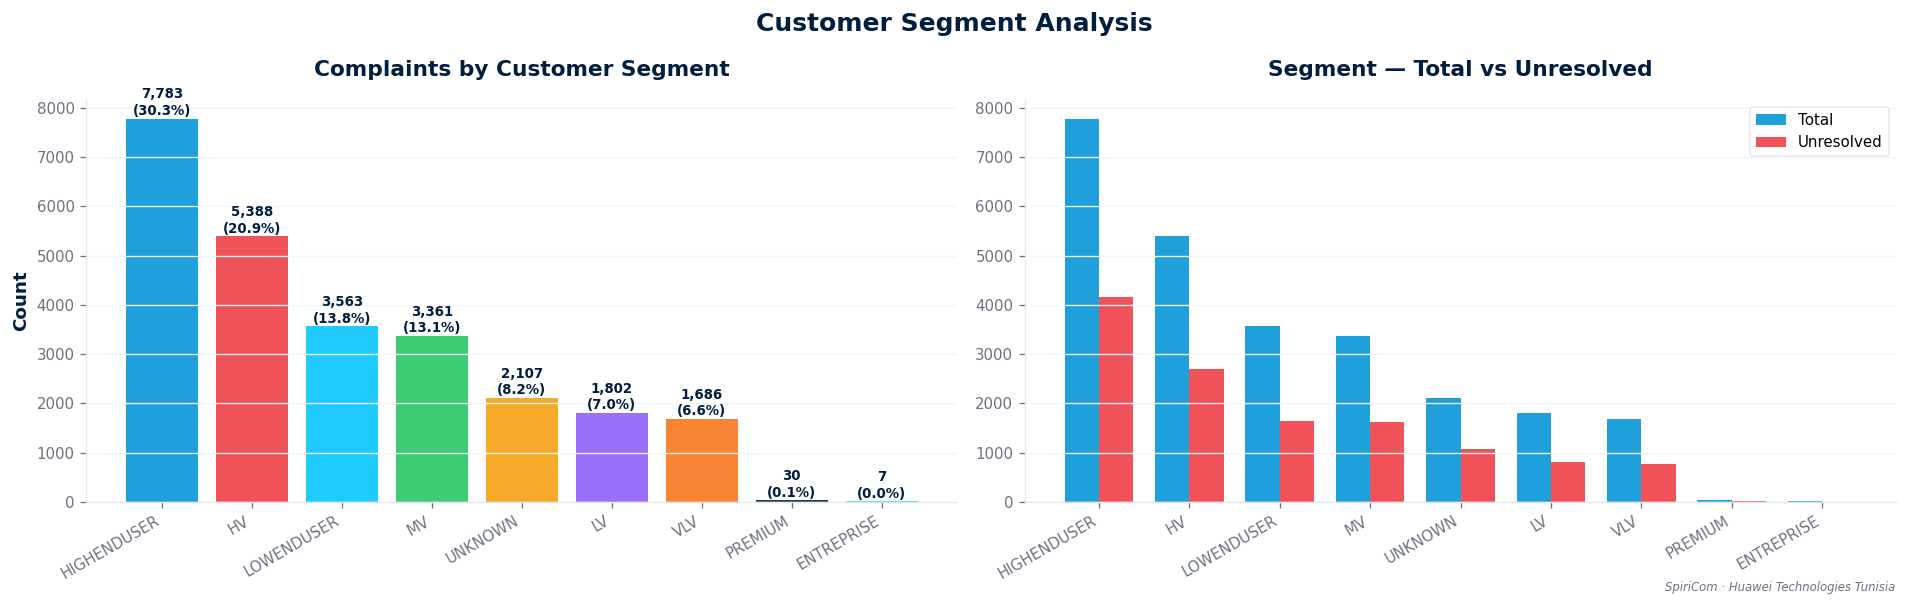

In [19]:
# ── 7.1  Segment distribution ─────────────────────────────────────────
if 'segment' in df.columns:
    seg = (df['segment'].dropna()
              .value_counts()
              .reset_index())
    seg.columns = ['segment', 'count']
    seg['pct'] = (seg['count'] / seg['count'].sum() * 100).round(1)

    seg_res = (df.dropna(subset=['segment'])
                 .groupby('segment')['is_unresolved']
                 .agg(['sum', 'count'])
                 .reset_index()
                 .rename(columns={'sum': 'unresolved', 'count': 'total'}))
    seg_res['unresolved_pct'] = (seg_res['unresolved'] / seg_res['total'] * 100).round(1)
    seg_res = seg_res.sort_values('total', ascending=False)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    ax = axes[0]
    colors_seg = [PALETTE[i % len(PALETTE)] for i in range(len(seg))]
    ax.bar(seg['segment'], seg['count'], color=colors_seg, alpha=0.88)
    for i, (_, row) in enumerate(seg.iterrows()):
        ax.text(i, row['count'] + seg['count'].max() * 0.01,
                f"{row['count']:,}\n({row['pct']}%)",
                ha='center', fontsize=8, color=HW['navy'], fontweight='bold')
    ax.set_title('Complaints by Customer Segment', pad=14)
    ax.set_ylabel('Count')
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

    ax2 = axes[1]
    x   = np.arange(len(seg_res))
    w   = 0.38
    ax2.bar(x - w/2, seg_res['total'],      width=w, color=HW['blue'], label='Total', alpha=0.88)
    ax2.bar(x + w/2, seg_res['unresolved'], width=w, color=HW['red'],  label='Unresolved', alpha=0.88)
    ax2.set_xticks(x)
    ax2.set_xticklabels(seg_res['segment'], rotation=30, ha='right')
    ax2.set_title('Segment — Total vs Unresolved', pad=14)
    ax2.legend()

    fig.suptitle('Customer Segment Analysis',
                 fontsize=15, fontweight='bold', color=HW['navy'])
    add_watermark(fig)
    plt.tight_layout()
    save_fig(fig, 'fig17_segment_analysis')
    plt.show()
else:
    print('No segment column found')

---
## 📊 Section 8 — Dashboard Summary Report
Export key statistics for the NOC Dashboard API.

In [20]:
# ── 8.1  Compile analysis_results.json ───────────────────────────────
from pathlib import Path
OUT_DIR = Path('data/outputs')
OUT_DIR.mkdir(parents=True, exist_ok=True)

def safe_dict(series, top=20):
    return series.dropna().value_counts().head(top).to_dict()

results = {
    'generated_at'     : datetime.now().isoformat(),
    'overview': {
        'total_complaints' : int(total),
        'date_min'         : str(date_min.date()),
        'date_max'         : str(date_max.date()),
        'date_range_days'  : int(date_range),
        'unique_msisdns'   : int(unique_msisdn),
        'n_provinces'      : int(n_provinces),
        'n_cities'         : int(n_cities),
        'n_categories'     : int(n_categories),
        'unresolved_total' : int(unresolved),
        'unresolved_pct'   : float(round(unresolved_pct, 2)),
    },
    'by_category'    : safe_dict(df['category'])    if 'category'       in df.columns else {},
    'by_province'    : safe_dict(df['province'])    if 'province'       in df.columns else {},
    'by_city'        : safe_dict(df['city'])        if 'city'           in df.columns else {},
    'by_provider'    : safe_dict(df['provider_group']) if 'provider_group' in df.columns else {},
    'by_segment'     : safe_dict(df['segment'])     if 'segment'        in df.columns else {},
    'by_status'      : safe_dict(df['status'])      if 'status'         in df.columns else {},
    'monthly_trend'  : {
        str(k): int(v)
        for k, v in df.set_index('opened_at').resample('M').size().items()
    },
    'dow_distribution': {
        ['Mon','Tue','Wed','Thu','Fri','Sat','Sun'][k]: int(v)
        for k, v in df['opened_at'].dt.dayofweek.value_counts().sort_index().items()
    },
}

out_path = OUT_DIR / 'analysis_results.json'
with open(out_path, 'w') as f:
    json.dump(results, f, indent=2, default=str)

print(f'✅ analysis_results.json saved: {out_path}')

✅ analysis_results.json saved: data\outputs\analysis_results.json


In [21]:
# ── 8.2  Final figure inventory ───────────────────────────────────────
figs = sorted(FIG_DIR.glob('*.png'))
htmls = sorted(FIG_DIR.glob('*.html'))

print('\n=== FIGURES GENERATED ===')
for f in figs:
    size_kb = f.stat().st_size // 1024
    print(f'  {f.name:<50s}  {size_kb:>5} KB')

print('\n=== INTERACTIVE HTML ===')
for f in htmls:
    size_kb = f.stat().st_size // 1024
    print(f'  {f.name:<50s}  {size_kb:>5} KB')

print(f'\n  Total static figures  : {len(figs)}')
print(f'  Total interactive     : {len(htmls)}')
print('\nNext → Run 02_KPI_Forecasting.ipynb')


=== FIGURES GENERATED ===
  fig01_kpi_tiles.png                                   166 KB
  fig02_daily_trend.png                                 575 KB
  fig03_01_msisdn_linkage.png                            90 KB
  fig03_02_churn_kpi_tiles.png                          169 KB
  fig03_03_churn_criteria.png                           225 KB
  fig03_04_churn_by_brand.png                           255 KB
  fig03_05_churn_by_zone.png                            393 KB
  fig03_06_churn_usage_behaviour.png                    288 KB
  fig03_07_churn_network_quality.png                    674 KB
  fig03_08_churn_by_generation.png                      133 KB
  fig03_09_churn_temporal.png                           334 KB
  fig03_10_correlation_heatmap.png                      476 KB
  fig03_monthly_trend.png                               290 KB
  fig03a_A_segment_profiles.png                         319 KB
  fig03a_B_province_heatmap.png                         722 KB
  fig03a_C_temporal_patterns

---
## Summary

| Section | Key Finding |
|---------|-------------|
| 1. Overview | Dataset scope, KPI tiles |
| 2. Time Series | Daily/weekly/monthly trends + peak detection |
| 3. Geographic | Province/city ranking + interactive treemap |
| 4. Categories | Pareto distribution + sub-category drill-down |
| 5. Providers | Volume vs resolution rate comparison |
| 6. Resolution | Status distribution + unresolved by category |
| 7. Segments | Corporate vs residential vs SME patterns |
| 8. Export | analysis_results.json → NOC Dashboard API |

All figures saved at **300 DPI** — thesis-ready.  
All charts follow the **Huawei brand palette** (#0093D5 / #EE3A43 / #001F3F).

---
*SpiriCom · NOC Intelligence Platform · Huawei Technologies Tunisia · PFE 2026*